Here, we run a very similar analysis to when we assessed adversarial removal of cell type and perturbation information. However, instead of checking whether these were removed, here, we're looking to see whether subtype information is retained (which would indicate that the model can predict subtype perturbation responses). 

In [1]:
import os
import math
import itertools
from tqdm import tqdm
import collections

import numpy as np
import pandas as pd
import scanpy as sc

from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import normalized_mutual_info_score

import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.insert(1, '../../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split, clear_adata

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.predict import (
    get_prediction, 
    merge_novar_predictions, 
    merge_ctrl_with_pert, 
    project_pls_per_condition)
from scLEMBAS import latent_separation as ls

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PLSRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

# csw = {
#     'max_components': 25 ,
#     'metric': 'accuracy', 
#     'method': 'elbow', 
#     'n_folds': 5, 
#     'seed': 888
# }

# assessment_kwargs = {
#     'n_perm': 100, 
#     'get_q2_pval': True, 
#     'get_r2_pval': False, 
#     'get_accuracy_pval': False,
#     'n_folds': 5, 
#     'seed': 888
# }

In [4]:
def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)




We rerun the assessment pipeline, but only on the subtypes within a cell type. 

We have to do each cell type independently because:
1) we have removed cell type information, technically, so can't merge across them
2) even without that, cell subtypes are distinct for each cell type, so there's an issue of either using them as different labels or the same


We apply the following filters when subsetting: must contain atleast 100 cells per subtype for classification quantification purposes

In [5]:
bias_res_all = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_biases.pickle'.format(author))
)

bias_res_all_noadv = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_biases_noadv.pickle'.format(author))
)

In [137]:
min_cell_subtypes = 50

bo_map = {'actual': bias_res_all, 'noadv': bias_res_all_noadv}
has_subtypes = ['Goblet', 'Club', 'Multiciliated']

bias_res_subtypes = {}
cv_res = []
counter = 0

for fold, mod_type in tqdm(itertools.product(range(5), ['actual', 'noadv'])):

    bias = bo_map[mod_type][fold]['bias_embedded']['global'].copy()
    bias = clear_adata(bias)
    del bias.uns['pca'], bias.uns['neighbors'], bias.uns['umap'], bias.uns['leiden']
    bias.obs = bias.obs.drop(columns = 'TF_clusters')

    bias.obs['secretory_mcc_subsets'] = tf_adata.obs.loc[bias.obs['vae_input_barcodes'].tolist(), 'secretory_mcc_subsets'].tolist()

    # exclude ones that don't have subtypes
    bias = bias[bias.obs[cat_col].isin(has_subtypes)].copy()

    for ct in has_subtypes:
        bias_sub = bias[bias.obs[cat_col] == ct].copy()
        if bias_sub.n_obs == 0 or bias_sub.obs.secretory_mcc_subsets.nunique() < 2:
            continue
        if not np.all(bias_sub.obs.secretory_mcc_subsets.value_counts() > min_cell_subtypes):
            continue

        bias_sub, _, cv_df_global = ls.pc_pipeline(
                    adata = bias_sub,
                    pert_ids = bias_sub.obs[pert_col].unique(), # don't subset
                    cat_ids = bias_sub.obs[cat_col].unique(), # don't subset
                    n_components = None, # estimate out of 50
                    pert_col = pert_col,
                    cat_col = cat_col,
                    get_hvgs = False, # tf activity doesn't use HVGs 
                    run_umap = True,
                    covariate_associations = ['secretory_mcc_subsets'], 
                    per_component_association = False, 
                    global_component_association = True,
                    file_prefix = None, #os.path.join(data_path, 'interim', '{}_bias_sub{}_fold{}_PC'.format(author, bias_sub_type, fold)),
                    verbose = True,
                    n_cores = n_cores,
                    seed = seed,
                    embkwrgs = {
                        'cluster_data': True, 
                        'n_neighbors': 15,
                        'resolution': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
                        'cluster_col_name': 'TF_clusters',
                        'nmi_label': 'condition', 
                        'scale': False, # TF activity is z-scored
                        'pcakwrgs': {
                            'use_highly_variable': False, # TF activity is z-scored
                            'zero_center': False # there are no HVGs so this is by default the behavior
                        }    
                    }
                )

        cv_df_global[cat_col] = ct
        cv_df_global['mod_type'] = mod_type
        cv_df_global['{}_fold'.format(author)] = fold
        cv_res.append(cv_df_global)

        bias_res_subtypes[counter] = {
            'fold': fold, 
            'mod_type': mod_type,
            cat_col: ct, 
            'anndata_obj': bias_sub
        }
        counter += 1
    
cv_res_all = pd.concat(cv_res)
cv_res_all.to_csv(os.path.join(data_path, 'processed', '{}_biassubtypePCA_probes.csv'.format(author)))
io.write_pickled_object(
    bias_res_subtypes, 
    os.path.join(data_path, 'processed', '{}_biasessubtypes.pickle'.format(author))
)

In [45]:
cv_res_all = pd.read_csv(os.path.join(data_path, 'processed', '{}_biassubtypePCA_probes.csv'.format(author)), index_col = 0)
bias_res_subtypes = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_biasessubtypes.pickle'.format(author))
)


In [46]:
cv_res_all.model_type = pd.Categorical(
    cv_res_all.model_type, 
    categories = ['linear', 'nonlinear'],
    ordered = True
).map(
    {
        'linear': 'Logistic Regression', 
        'nonlinear': 'Random Forest'}
)

cv_res_all.mod_type = pd.Categorical(
    cv_res_all.mod_type, 
    categories = ['actual', 'noadv'],
    ordered = True
).map(
    {
        'actual': 'scLEMBAS', 
        'noadv': 'No Adversarial Removal Baseline'}
)

Stats comparisons are no within each cell type within each fold (still fewer comparisons than original, so not biased by multiple test correction). And we now use a two-sided MWU test rather than a one-sided one. 

In [47]:
# test = []

In [48]:
stats_res = collections.defaultdict(list)

for idx, bs in bias_res_subtypes.items():
    big_fold = bs['fold']
    ct = bs[cat_col]
    
    mask_ = (cv_res_all['{}_fold'.format(author)] == big_fold) & (cv_res_all[cat_col] == ct)
    for classifier_type  in (['Logistic Regression', 'Random Forest']):
        mask = mask_ & (cv_res_all['model_type'] == classifier_type)
        
        stats_df = cv_res_all[mask].copy()
        actual_mask = (stats_df.mod_type == 'scLEMBAS')
        
        a = stats_df[actual_mask]['{}_balanced_accuracy'.format('secretory_mcc_subsets')]
        b = stats_df[~actual_mask]['{}_balanced_accuracy'.format('secretory_mcc_subsets')]

        cd = cohens_d_paired(a,b)
        pval = stats.wilcoxon(a, b, alternative = 'two-sided').pvalue# stats.mannwhitneyu(a, b, alternative = 'two-sided').pvalue

        stats_res['paired_cohen_d'].append(cd)
        stats_res['mwu_pval'].append(pval)

        stats_res[cat_col].append(ct)
        stats_res['classifier_type'].append(classifier_type)
        stats_res['fold'].append(big_fold) 
        
#         test.append(stats_df)
        
stats_res = pd.DataFrame(stats_res)  
_, fdr, _, _ = multipletests(stats_res.mwu_pval, method = 'fdr_bh')
stats_res['bh_fdr'] = fdr


In [49]:
stats_res.paired_cohen_d.mean()

-5.026849485674473

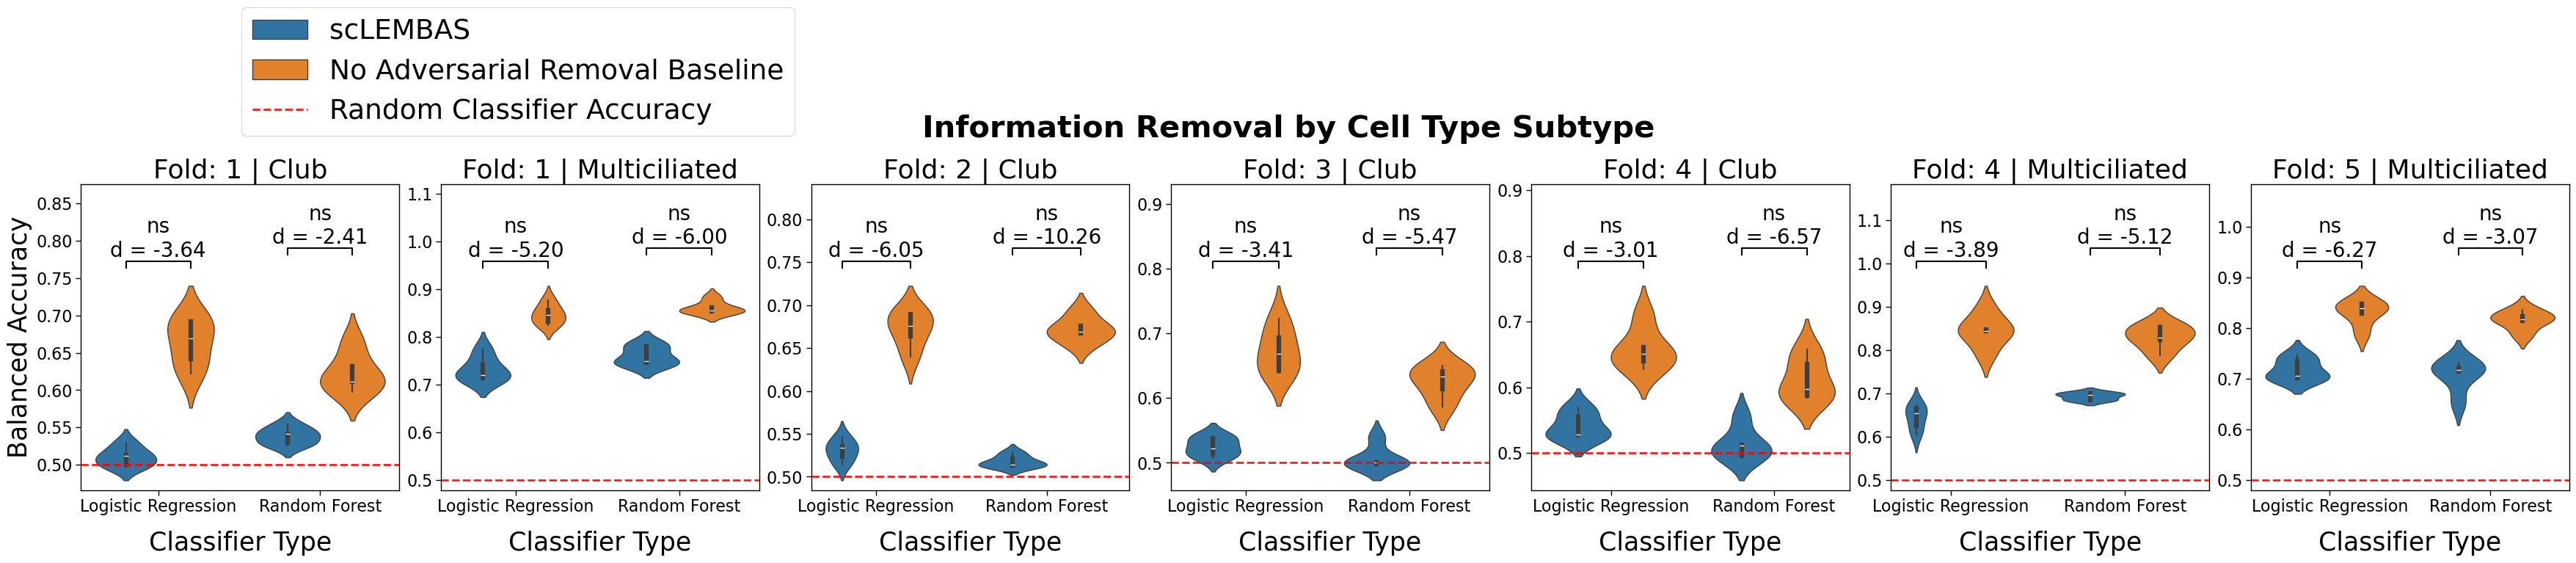

In [87]:
with sns.plotting_context(
    "paper", font_scale=1.3,
    rc={
        "axes.labelsize": 25,
        "axes.titlesize": 26,
        "legend.fontsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
):

    def _sig_stars(q):
        if q <= 0.001:
            return "***"
        elif q <= 0.01:
            return "**"
        elif q <= 0.05:
            return "*"
        else:
            return "ns"

    def _add_bracket(ax, x1, x2, y, h, text):
        ax.plot(
            [x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5,
            c="black",
            clip_on=False
        )
        ax.text(
            (x1 + x2) / 2,
            y + h,
            text,
            ha="center",
            va="bottom",
            fontsize=20,
            clip_on=False
        )

    # ---- y-axis padding toggle for brackets ----
    AUTO_YMAX_FOR_BRACKETS = True
    BRACKET_YMAX_PAD = 0.35  # increase to 0.45/0.55 if bracket labels still clip

    # ---- reference-line toggles ----
    SHOW_FIXED_05_LINE = True
    SHOW_RANDOM_CLASSIFIER_LINE = True

    # ---- layout calculation ----
    cols = ['cell_type', '{}_fold'.format(author)]
    unique_vals = cv_res_all[cols].drop_duplicates()
    n_panels = unique_vals.shape[0]
    unique_vals = list(zip(unique_vals[cols[0]], unique_vals[cols[1]]))

    # ---- force 7 columns in one row ----
    ncols = 7
    nrows = 1

    fig, ax = plt.subplots(
        ncols=ncols,
        nrows=nrows,
        figsize=(5 * ncols, 5.5),
        constrained_layout=True
    )

    ax = np.array(ax).flatten()

    # hide any unused axes
    for i in range(n_panels, len(ax)):
        ax[i].set_visible(False)

    chance_handle = None
    fixed_05_handle = None
    _ycol = 'secretory_mcc_subsets_balanced_accuracy'

    for idx, (ct, big_fold) in enumerate(unique_vals):
        if idx >= len(ax):
            break

        mask = (
            (cv_res_all['{}_fold'.format(author)] == big_fold) &
            (cv_res_all[cat_col] == ct)
        )
        viz_df = cv_res_all[mask].copy()

        sns.violinplot(
            data=viz_df,
            x='model_type',
            y=_ycol,
            hue='mod_type',
            ax=ax[idx],
            zorder=0
        )

        # ---- fixed 0.5 reference line ----
        if SHOW_FIXED_05_LINE:
            line_05 = ax[idx].axhline(
                0.5,
                linestyle="--",
                linewidth=2,
                color="red",
                alpha=0.9,
                zorder=100
            )

            if fixed_05_handle is None:
                fixed_05_handle = line_05

        ax[idx].set_ylabel('Balanced Accuracy')
        ax[idx].set_xlabel('Classifier Type', labelpad=15)
        ax[idx].set_title('Fold: {} | {}'.format(big_fold + 1, ct))

        # ---- bracket annotations ----
        _tick_pos = ax[idx].get_xticks()
        _tick_lbls = [t.get_text() for t in ax[idx].get_xticklabels()]
        _xmap = dict(zip(_tick_lbls, _tick_pos))

        _y0, _y1 = ax[idx].get_ylim()
        _yrng = _y1 - _y0 if (_y1 - _y0) != 0 else 0.1

        _brk_k = 0
        for _clf in _tick_lbls:
            _s = stats_res[
                (stats_res[cat_col] == ct) &
                (stats_res['fold'] == big_fold) &
                (stats_res['classifier_type'] == _clf)
            ]

            if _s.shape[0] == 0:
                continue

            _q = float(_s.bh_fdr.values[0])
            _d = float(_s.paired_cohen_d.values[0])
            _stars = _sig_stars(_q)

            _x = _xmap.get(_clf, None)
            if _x is None:
                continue

            _y = _y1 + (0.04 + 0.06 * _brk_k) * _yrng
            _h = 0.03 * _yrng
            _brk_k += 1

            _add_bracket(
                ax[idx],
                _x - 0.20,
                _x + 0.20,
                _y,
                _h,
                "{}\nd = {:.2f}".format(_stars, _d)
            )

        if AUTO_YMAX_FOR_BRACKETS:
            ymax_pad = BRACKET_YMAX_PAD + 0.08 * max(_brk_k - 1, 0)
            ax[idx].set_ylim(_y0, _y1 + ymax_pad * _yrng)
        else:
            ax[idx].set_ylim(_y0, _y1)

        # ---- random classifier/chance line ----
        subtype_classes = (
            viz_df['secretory_mcc_subsets'].nunique()
            if 'secretory_mcc_subsets' in viz_df.columns
            else None
        )
        chance = 1 / subtype_classes if subtype_classes else None

        if SHOW_RANDOM_CLASSIFIER_LINE and chance is not None:
            line = ax[idx].axhline(
                chance,
                linestyle="--",
                linewidth=2,
                color="red",
                alpha=0.9,
                zorder=101
            )

            if chance_handle is None:
                chance_handle = line

            _ylim0, _ylim1 = ax[idx].get_ylim()
            ax[idx].set_ylim(min(_ylim0, chance - 0.02), _ylim1)

        # ---- legend cleanup ----
        leg = ax[idx].get_legend()
        if leg is not None:
            leg.set_title("Model Type")

        if idx != 0 and ax[idx].get_legend() is not None:
            ax[idx].legend_.remove()

        # ---- axis label cleanup: suppress redundant labels ----
        col_pos = idx % ncols

        if col_pos != 0:
            ax[idx].set_ylabel('')

        # because this is one row, keep all x labels visible
        ax[idx].set_xlabel('Classifier Type', labelpad=15)

    # ---- figure-level legend ----
    leg = ax[0].get_legend()

    handles = []
    labels = []

    if leg is not None:
        handles.extend(leg.legend_handles)
        labels.extend([t.get_text() for t in leg.get_texts()])

    if chance_handle is not None:
        handles.append(chance_handle)
        labels.append("Random Classifier Accuracy")

    if fixed_05_handle is not None:
        handles.append(fixed_05_handle)
        labels.append("Random Classifier Accuracy")

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=1,
        fontsize=27,
        bbox_to_anchor=(0.2, 1.4)
    )

    if ax[0].get_legend() is not None:
        ax[0].legend_.remove()

    fig.suptitle(
        'Information Removal by Cell Type Subtype',
        fontsize=30,
        fontweight='bold',
        y=1.1
    )

fig.savefig(
    os.path.join(
        data_path,
        'figures',
        '{}_adversarial_removal_subtype_all_probes.png'.format(author)
    ),
    dpi=600,
    bbox_inches='tight'
)

We can see that, unlike the cell type removal, here, we do not get significant differences with the adversarial model. Caveats include: 
1) some of the models are already at or near the balanced accuracy random chance -- these are the club cells, that have a class imbalance of 0.92 vs that of Multiciliated with 0.75
2) Cohen's d effect sizes are still large, though on average substantially smaller than cell type (mean of -5.0 vs -19.1)

/tmp/ipykernel_3108468/2371626623.py:88: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.12)  # space for legend


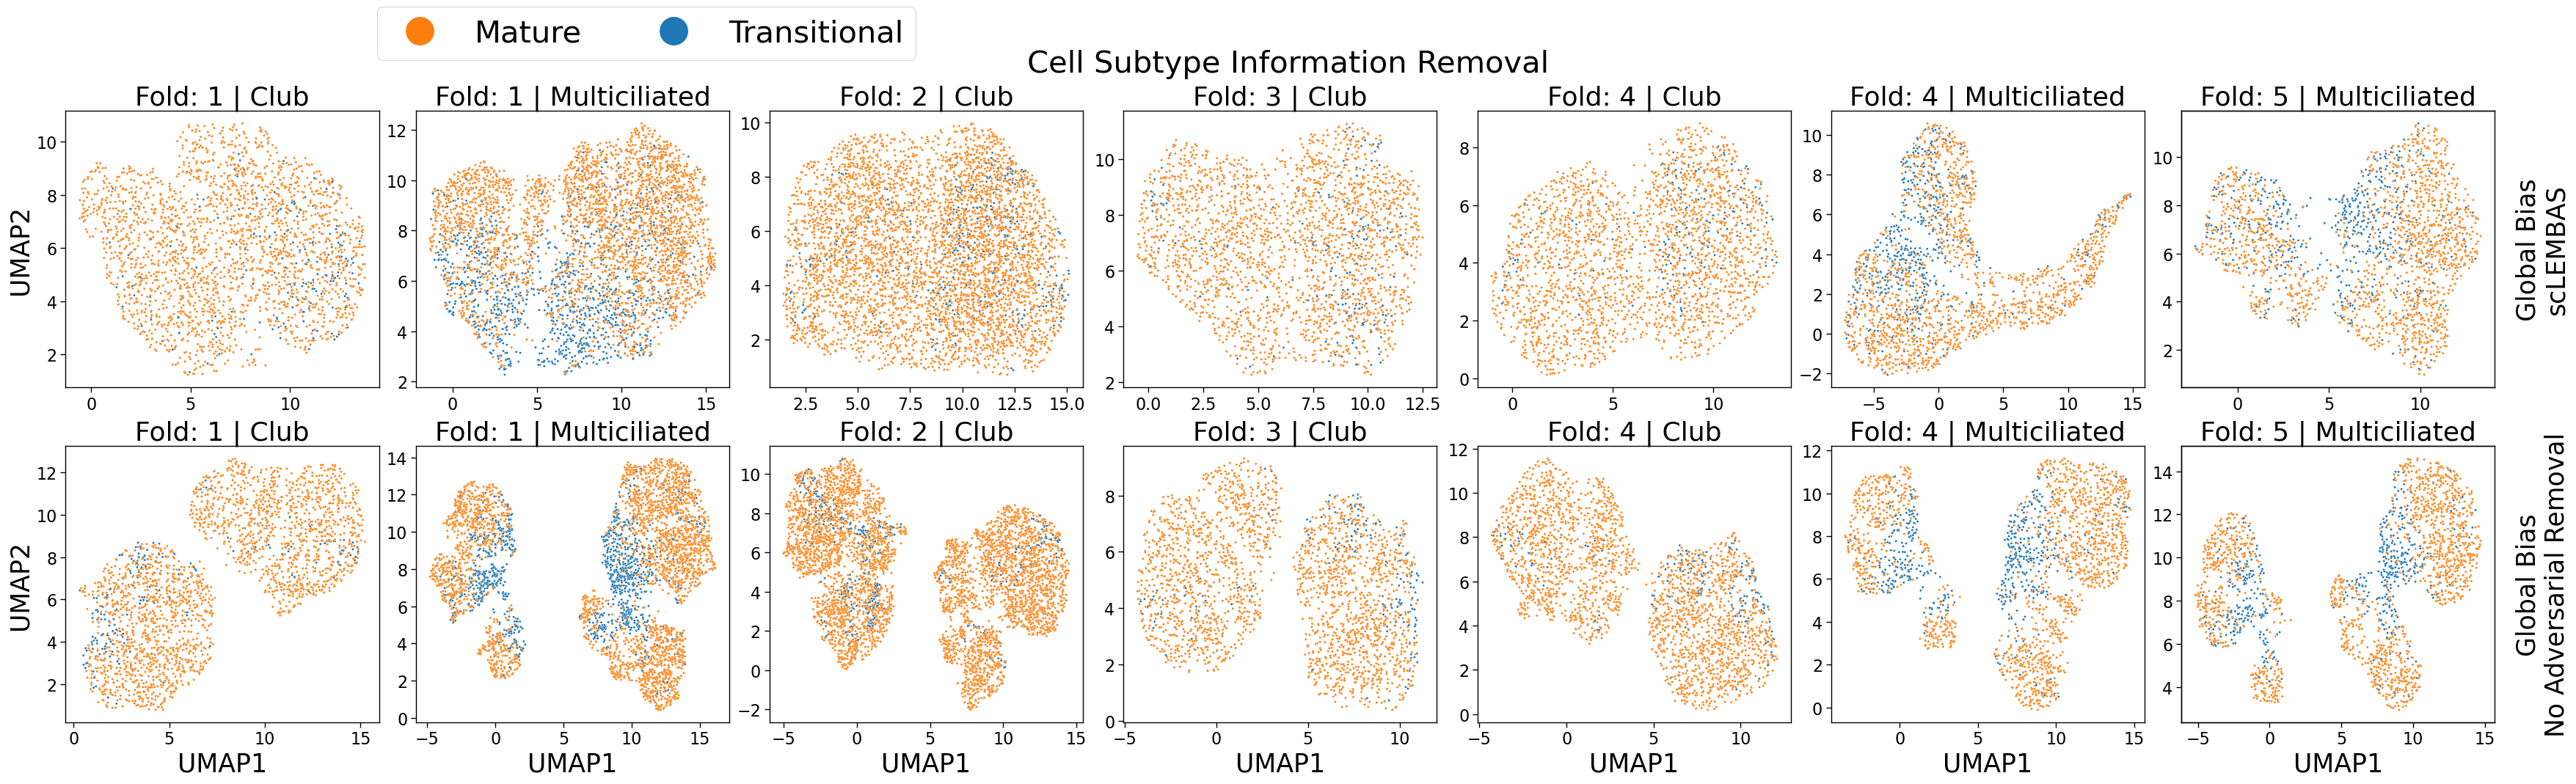

In [55]:
from matplotlib.lines import Line2D

mod_type_map = {
    'actual': 'Global Bias\nscLEMBAS',
    'noadv': 'Global Bias\nNo Adversarial Removal'
}


def generate_umap(bias):
    X_umap = pd.DataFrame(
        bias.obsm['X_umap'],
        columns=['UMAP{}'.format(i + 1) for i in range(2)]
    )

    vals = pd.Series(bias.obs['secretory_mcc_subsets'].astype(str)).str.lower()

    cleaned_vals = np.where(
        vals.str.contains('mature'),
        'Mature',
        np.where(
            vals.str.contains('transitional'),
            'Transitional',
            bias.obs['secretory_mcc_subsets'].astype(str)
        )
    )

    X_umap['Cell Subtype'] = cleaned_vals

    nmis = {}
    nmis['secretory_mcc_subsets'] = normalized_mutual_info_score(
        cleaned_vals,
        bias.obs['TF_clusters']
    )

    return X_umap, nmis


# fixed label
col_label = 'Cell Subtype'

sns.set_context(
    "paper",font_scale=1.7,
    rc={
        "axes.labelsize": 25,
        "axes.titlesize": 26,
        "legend.fontsize": 18,
        "legend.title_fontsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
)

# ---------------------------
# organize entries
# ---------------------------
plot_items = []
for idx, bs in bias_res_subtypes.items():
    plot_items.append({
        'fold': bs['fold'],
        'cell_type': bs[cat_col],
        'mod_type': bs['mod_type'],
        'anndata_obj': bs['anndata_obj'],
    })

plot_df = pd.DataFrame(plot_items)

# fold-celltype combinations = columns
col_combos = (
    plot_df[['fold', 'cell_type']]
    .drop_duplicates()
    .sort_values(['fold', 'cell_type'])
    .reset_index(drop=True)
)

# mod types = rows
row_mod_types = sorted(plot_df['mod_type'].unique())

assert len(row_mod_types) == 2
assert len(col_combos) == 7

fig, ax = plt.subplots(
    nrows=2,
    ncols=7,
    figsize=(35, 10),
    constrained_layout=True
)

fig.subplots_adjust(left=0.12)  # space for legend

ax = np.array(ax).reshape(2, 7)

# consistent color mapping
palette = {
    'Transitional': sns.color_palette()[0],  # first color
    'Mature': sns.color_palette()[1],
}

for j, (_, combo_row) in enumerate(col_combos.iterrows()):
    fold = combo_row['fold']
    ct = combo_row['cell_type']

    for i, mod_type in enumerate(row_mod_types):
        curr = plot_df[
            (plot_df['fold'] == fold) &
            (plot_df['cell_type'] == ct) &
            (plot_df['mod_type'] == mod_type)
        ]

        assert curr.shape[0] == 1

        bias_obj = curr.iloc[0]['anndata_obj']
        bias_umap, bias_nmis = generate_umap(bias_obj)

        sns.scatterplot(
            data=bias_umap,
            x='UMAP1',
            y='UMAP2',
            hue='Cell Subtype',
            hue_order=['Transitional', 'Mature'],
            palette=palette,
            s=5,
            ax=ax[i, j],
            legend=False
        )

#         ax[i, j].annotate(
#             'NMI: {:.2f}'.format(bias_nmis['secretory_mcc_subsets']),
#             xy=(0.02, 0.02),
#             xycoords="axes fraction",
#             ha="left",
#             va="bottom",
#             fontsize=12
#         )

        ax[i, j].set_title('Fold: {} | {}'.format(fold + 1, ct))

        # right-side row labels
        if j == len(col_combos) - 1:
            ax_r = ax[i, j].twinx()
            ax_r.set_ylabel(mod_type_map[mod_type], labelpad=20)
            ax_r.set_yticks([])
            ax_r.tick_params(right=False)
            ax_r.spines['right'].set_visible(False)

        # axis cleanup
        if i != 1:
            ax[i, j].set_xlabel('')
        if j != 0:
            ax[i, j].set_ylabel('')


# ---------------------------
# figure-level legend (LEFT)
# ---------------------------
handles = [
    Line2D([0], [0], marker='o', linestyle='',
           color=palette['Mature'], label='Mature',
           markersize=18),
    Line2D([0], [0], marker='o', linestyle='',
           color=palette['Transitional'], label='Transitional',
           markersize=18),
]

fig.legend(
    handles=handles,
    loc='upper center',
    ncols = 2,
    fontsize=30, 
    markerscale = 1.5,
    bbox_to_anchor=(0.25, 1.075),
    frameon=True
)

fig.suptitle('Cell Subtype Information Removal', fontsize=30)
fig.savefig(os.path.join(
    data_path, 'figures', '{}_adversarial_removal_subtype_all_umaps.png'.format(author)), 
            dpi=600, bbox_inches='tight'
           )
plt.show()


In [21]:
fold = 0
ct = 'Multiciliated'

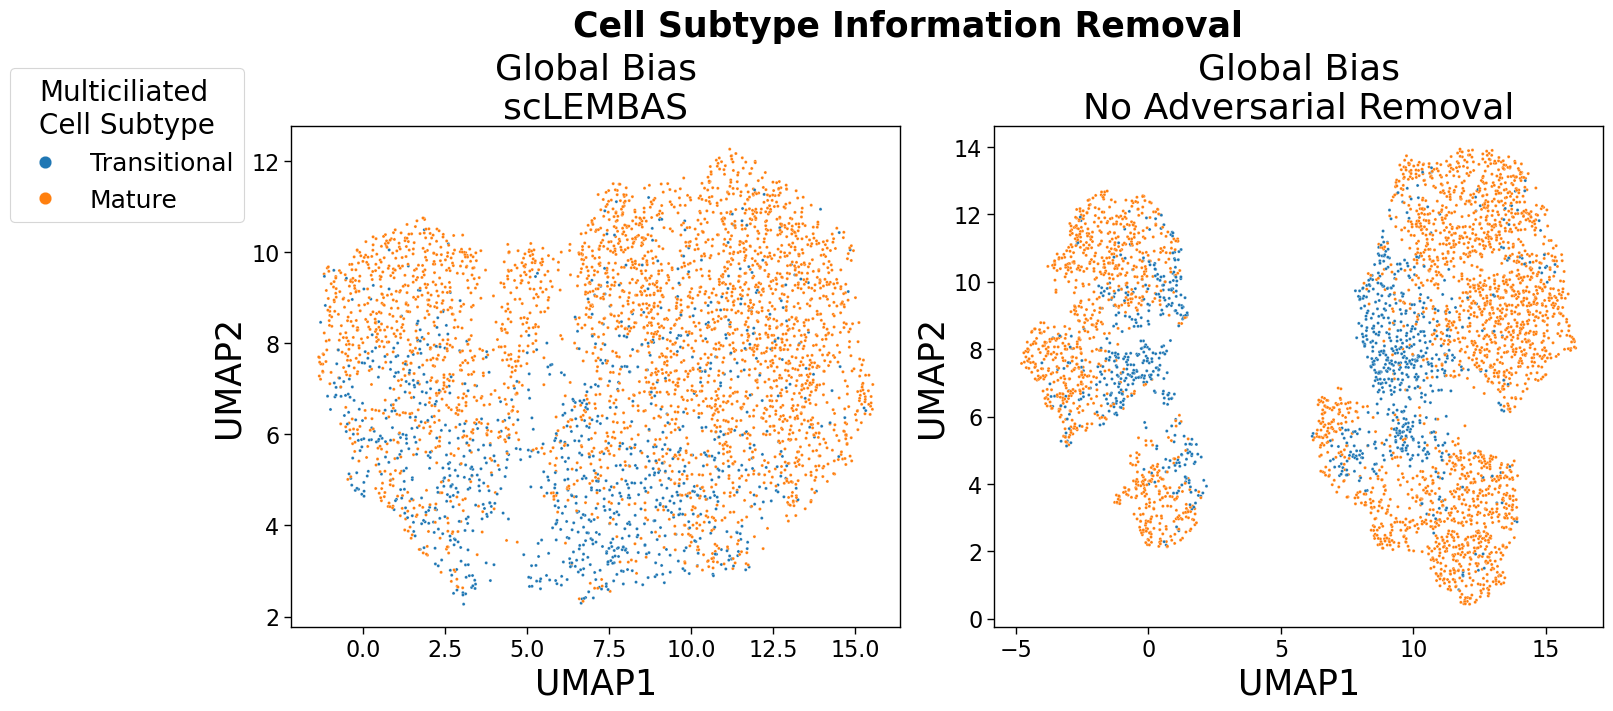

In [33]:

mod_type_map = {
    'actual': 'Global Bias',
    'noadv': 'Global Bias\nNo Adversarial Removal'
}


def generate_umap(bias):
    X_umap = pd.DataFrame(
        bias.obsm['X_umap'],
        columns=['UMAP{}'.format(i + 1) for i in range(2)]
    )

    vals = pd.Series(bias.obs['secretory_mcc_subsets'].astype(str)).str.lower()

    cleaned_vals = np.where(
        vals.str.contains('mature'),
        'Mature',
        np.where(
            vals.str.contains('transitional'),
            'Transitional',
            bias.obs['secretory_mcc_subsets'].astype(str)
        )
    )

    X_umap['Cell Subtype'] = cleaned_vals

    nmis = {}
    nmis['secretory_mcc_subsets'] = normalized_mutual_info_score(
        cleaned_vals,
        bias.obs['TF_clusters']
    )

    return X_umap, nmis


# fixed label
col_label = 'Cell Subtype'

# consistent color mapping
palette = {
    'Transitional': sns.color_palette()[0],  # first color
    'Mature': sns.color_palette()[1],
}

# ---------------------------
# organize entries
# ---------------------------
plot_items = []
for idx, bs in bias_res_subtypes.items():
    plot_items.append({
        'fold': bs['fold'],
        'cell_type': bs[cat_col],
        'mod_type': bs['mod_type'],
        'anndata_obj': bs['anndata_obj'],
    })

plot_df = pd.DataFrame(plot_items)

# panel order: 'actual' (Global Bias) on the left, 'noadv' on the right
panel_mod_types = ['actual', 'noadv']

with sns.plotting_context(
    "paper",
    rc={
        "axes.labelsize": 25,
        "axes.titlesize": 26,
        "legend.fontsize": 18,
        "legend.title_fontsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
):
    fig = plt.figure(figsize=(14, 7), constrained_layout=True)

    gs = fig.add_gridspec(
        nrows=1,
        ncols=2,
        width_ratios=[1, 1]
    )

    ax = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
    ]

    handles, labels = None, None

    for j, mod_type in enumerate(panel_mod_types):
        curr = plot_df[
            (plot_df['fold'] == fold) &
            (plot_df['cell_type'] == ct) &
            (plot_df['mod_type'] == mod_type)
        ]

        assert curr.shape[0] == 1

        bias_obj = curr.iloc[0]['anndata_obj']
        bias_umap, bias_nmis = generate_umap(bias_obj)

        sns.scatterplot(
            data=bias_umap,
            x='UMAP1',
            y='UMAP2',
            hue='Cell Subtype',
            hue_order=['Transitional', 'Mature'],
            palette=palette,
            s=5,
            ax=ax[j]
        )

#         ax[j].annotate(
#             'NMI: {:.2f}'.format(bias_nmis['secretory_mcc_subsets']),
#             xy=(0.02, 0.02),
#             xycoords="axes fraction",
#             ha="left",
#             va="bottom",
#             fontsize=25
#         )

        # match title style
        title = mod_type_map[mod_type]
        if title == 'Global Bias':
            ax[j].set_title('Global Bias\nscLEMBAS')
        else:
            ax[j].set_title(title)

        # capture legend, then strip the per-axis one
        handles, labels = ax[j].get_legend_handles_labels()
        if ax[j].get_legend() is not None:
            ax[j].legend_.remove()

#         if j != 0:
#             ax[j].set_ylabel('')

    # shared legend, placed OUTSIDE to the LEFT of ax[0]
    fig.canvas.draw()  # resolve layout so ax[0] position is accurate
    pos0 = ax[0].get_position()
    fig.legend(
        handles, labels,
        markerscale=4,
        title=col_label.replace('Cell', '{}\nCell'.format(ct)),
        loc='center right',
        bbox_to_anchor=(pos0.x0 - 0.025, 0.8)
    )

    fig.suptitle(
        'Cell Subtype Information Removal'.format(fold + 1, ct),
        fontsize=25,
        fontweight='bold'
    )

plt.show()
fig.savefig(os.path.join(
    data_path, 'figures', '{}_adversarial_removal_subtype_main_fold{}_ct{}.png'.format(author, fold, ct)), 
            dpi=600, bbox_inches='tight'
           )
